In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import shap
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

/home/utn/kocy61ry/Documents/ML Project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_2020 = pd.read_csv('data/delta_table_2020_3x3.csv')
df_2021 = pd.read_csv('data/delta_table_2021_3x3.csv')

df_2021 = df_2021[df_2021['delta_years'] != 5]

In [3]:
df_2020 = df_2020.drop(columns=['year', "system:index", "image_count", ".geo", "geometry", "x", "y"])
df_2020 = df_2020.fillna(df_2020.mean())

df_2021 = df_2021.drop(columns=['year', "system:index", "image_count", ".geo", "geometry", "x", "y"])
df_2021 = df_2021.fillna(df_2021.mean())

In [4]:
df_2020['vegetation'] = df_2020[['tree_cover', 'cropland', 'grassland']].sum(axis=1)
df_2021['vegetation'] = df_2021[['tree_cover', 'cropland', 'grassland']].sum(axis=1)

target_labels = [
    'built_up',
    'vegetation',
    'water'
]

remaining_target = [
    'bare_sparse_vegetation',
    'tree_cover',
    'grassland',
    'cropland'
]


In [5]:
# --- Feature Engineering for df_2020 ---
# Vegetation Indices
df_2020['NDVI'] = (df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + df_2020['B4'] + 1e-8)
# df_2020['EVI'] = 2.5 * ((df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + 6 * df_2020['B4'] - 7.5 * df_2020['B2'] + 1 + 1e-8))
df_2020['EVI2'] = 2.5 * ((df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + 2.4 * df_2020['B4'] + 1 + 1e-8))
df_2020['SAVI'] = ((df_2020['B8'] - df_2020['B4']) * 1.5) / (df_2020['B8'] + df_2020['B4'] + 0.5 + 1e-8)
# df_2020['NDRE'] = (df_2020['B8'] - df_2020['B5']) / (df_2020['B8'] + df_2020['B5'] + 1e-8)
# df_2020['GNDVI'] = (df_2020['B8'] - df_2020['B3']) / (df_2020['B8'] + df_2020['B3'] + 1e-8)

# Urban & Built-up Indices
df_2020['NDBI'] = (df_2020['B11'] - df_2020['B8']) / (df_2020['B11'] + df_2020['B8'] + 1e-8)

# Water & Moisture Indices
df_2020['NDWI'] = (df_2020['B3'] - df_2020['B8']) / (df_2020['B3'] + df_2020['B8'] + 1e-8)
df_2020['MNDWI'] = (df_2020['B3'] - df_2020['B11']) / (df_2020['B3'] + df_2020['B11'] + 1e-8)


# --- Feature Engineering for df_2021 ---
# Vegetation Indices
df_2021['NDVI'] = (df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + df_2021['B4'] + 1e-8)
# df_2021['EVI'] = 2.5 * ((df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + 6 * df_2021['B4'] - 7.5 * df_2021['B2'] + 1 + 1e-8))
df_2021['EVI2'] = 2.5 * ((df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + 2.4 * df_2021['B4'] + 1 + 1e-8))
df_2021['SAVI'] = ((df_2021['B8'] - df_2021['B4']) * 1.5) / (df_2021['B8'] + df_2021['B4'] + 0.5 + 1e-8)
# df_2021['NDRE'] = (df_2021['B8'] - df_2021['B5']) / (df_2021['B8'] + df_2021['B5'] + 1e-8)
# df_2021['GNDVI'] = (df_2021['B8'] - df_2021['B3']) / (df_2021['B8'] + df_2021['B3'] + 1e-8)

# Urban & Built-up Indices
df_2021['NDBI'] = (df_2021['B11'] - df_2021['B8']) / (df_2021['B11'] + df_2021['B8'] + 1e-8)

# Water & Moisture Indices
df_2021['NDWI'] = (df_2021['B3'] - df_2021['B8']) / (df_2021['B3'] + df_2021['B8'] + 1e-8)
df_2021['MNDWI'] = (df_2021['B3'] - df_2021['B11']) / (df_2021['B3'] + df_2021['B11'] + 1e-8)

In [6]:
X_train = df_2020.drop(columns=target_labels + remaining_target)
X_train = X_train.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
y_train = df_2020[target_labels]

X_test = df_2021.drop(columns=target_labels + remaining_target)
X_test = X_test.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
y_test = df_2021[target_labels]

In [7]:
X_train.columns, y_train.columns

(Index(['delta_years', 'B11', 'B12', 'B2', 'B3', 'B5', 'B6', 'B11_m1_m1',
        'B12_m1_m1', 'B2_m1_m1', 'B3_m1_m1', 'B4_m1_m1', 'B5_m1_m1', 'B6_m1_m1',
        'B7_m1_m1', 'B8_m1_m1', 'B11_p0_m1', 'B12_p0_m1', 'B2_p0_m1',
        'B3_p0_m1', 'B4_p0_m1', 'B5_p0_m1', 'B6_p0_m1', 'B7_p0_m1', 'B8_p0_m1',
        'B11_p1_m1', 'B12_p1_m1', 'B2_p1_m1', 'B3_p1_m1', 'B4_p1_m1',
        'B5_p1_m1', 'B6_p1_m1', 'B7_p1_m1', 'B8_p1_m1', 'B11_m1_p0',
        'B12_m1_p0', 'B2_m1_p0', 'B3_m1_p0', 'B4_m1_p0', 'B5_m1_p0', 'B6_m1_p0',
        'B7_m1_p0', 'B8_m1_p0', 'B11_p1_p0', 'B12_p1_p0', 'B2_p1_p0',
        'B3_p1_p0', 'B4_p1_p0', 'B5_p1_p0', 'B6_p1_p0', 'B7_p1_p0', 'B8_p1_p0',
        'B11_m1_p1', 'B12_m1_p1', 'B2_m1_p1', 'B3_m1_p1', 'B4_m1_p1',
        'B5_m1_p1', 'B6_m1_p1', 'B7_m1_p1', 'B8_m1_p1', 'B11_p0_p1',
        'B12_p0_p1', 'B2_p0_p1', 'B3_p0_p1', 'B4_p0_p1', 'B5_p0_p1', 'B6_p0_p1',
        'B7_p0_p1', 'B8_p0_p1', 'B11_p1_p1', 'B12_p1_p1', 'B2_p1_p1',
        'B3_p1_p1', 'B4_p1_p1', 'B5

In [8]:
import pickle

with open('models/all_benchmark_models_delta.pkl', 'rb') as f:
    loaded_models = pickle.load(f)

loaded_models

{'Linear Regression': Pipeline(steps=[('scaler', StandardScaler()), ('lr', LinearRegression())]),
 'Ridge Regression': Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge())]),
 'Lasso Regression': Pipeline(steps=[('scaler', StandardScaler()),
                 ('lasso', Lasso(alpha=0.1, max_iter=10000))]),
 'KNN': Pipeline(steps=[('scaler', StandardScaler()),
                 ('knn',
                  KNeighborsRegressor(leaf_size=24, n_jobs=-1, n_neighbors=28))]),
 'Random Forest': RandomForestRegressor(max_depth=9, max_features=0.6061272316154472,
                       min_samples_leaf=8, min_samples_split=14,
                       n_estimators=390, n_jobs=-1, random_state=42),
 'XGBoost': MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                             callbacks=None,
                                             colsample_bylevel=None,
                                             colsample_bynode=None,
              

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from tqdm import tqdm

current_labels = [
    'built_up',
    'vegetation',
    'water'
]

def evaluate_and_plot_all_models(models_dict, X_test, y_test, class_labels):
    """
    Predicts using all models, generates Confusion Matrices, 
    and returns a performance summary DataFrame.
    """
    os.makedirs("model_evaluation_plots", exist_ok=True)
    performance_results = []
    
    true_dominant = y_test[class_labels].idxmax(axis=1).reset_index(drop=True)
  
    plt.rcParams.update({
        "font.size": 9,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "legend.fontsize": 9,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.grid": False,
        "figure.facecolor": "white",
        "axes.facecolor": "#F5F5F5",
    })

    # Wrap the dictionary items with tqdm for a progress bar
    for name, model in tqdm(models_dict.items(), desc="Evaluating Models"):
        y_pred_array = model.predict(X_test)
        y_pred_df = pd.DataFrame(y_pred_array, columns=class_labels)
        pred_dominant = y_pred_df.idxmax(axis=1)

        acc = accuracy_score(true_dominant, pred_dominant)
        f1 = f1_score(true_dominant, pred_dominant, average='weighted')
        
        performance_results.append({
            'Model': name,
            'Accuracy': acc,
            'F1_Score': f1
        })

        fig, ax = plt.subplots(figsize=(8, 7))
        cm_data = confusion_matrix(true_dominant, pred_dominant, labels=class_labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_data, display_labels=class_labels)
        
        disp.plot(cmap='Blues', xticks_rotation=45, ax=ax, colorbar=False)
        ax.set_title(f'Dominant Class CM: {name}', fontweight='bold')
        
        for side in ("top", "right", "bottom", "left"):
            ax.spines[side].set_visible(True)
            ax.spines[side].set_color("black")
            ax.spines[side].set_linewidth(1.2)
        ax.tick_params(axis="both", which="major", length=4, width=1.0)

        plt.tight_layout()
        save_path = f"model_evaluation_plots/cm_{name.lower().replace(' ', '_')}.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig) 

    return pd.DataFrame(performance_results)

performance_df = evaluate_and_plot_all_models(loaded_models, X_test, y_test, current_labels)

Evaluating Models: 100%|██████████| 6/6 [32:02<00:00, 320.35s/it]


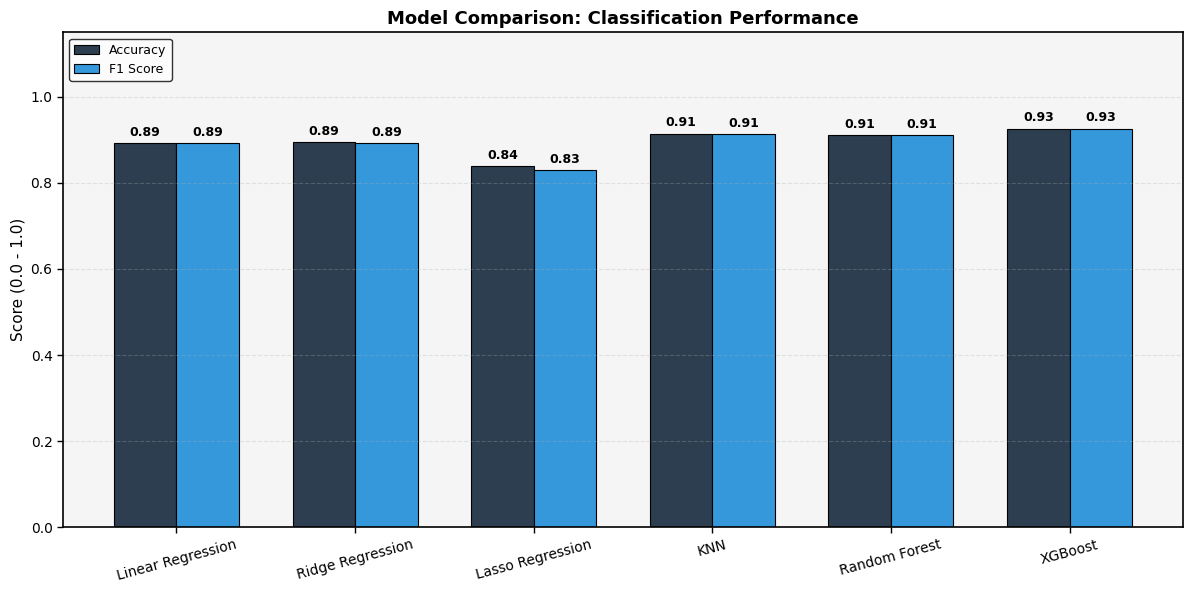

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

models = performance_df['Model']
x = np.arange(len(models))
width = 0.35

# Plotting the bars
rects1 = ax.bar(x - width/2, performance_df['Accuracy'], width, 
                label='Accuracy', color='#2c3e50', edgecolor='black', linewidth=0.8)
rects2 = ax.bar(x + width/2, performance_df['F1_Score'], width, 
                label='F1 Score', color='#3498db', edgecolor='black', linewidth=0.8)

# --- NEW: Add the values to the top of the bars ---
ax.bar_label(rects1, padding=3, fmt='%.2f', fontsize=9, fontweight='bold')
ax.bar_label(rects2, padding=3, fmt='%.2f', fontsize=9, fontweight='bold')
# --------------------------------------------------

ax.set_title("Model Comparison: Classification Performance", fontweight='bold', fontsize=13)
ax.set_ylabel("Score (0.0 - 1.0)")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.set_ylim(0, 1.15) # Increased slightly to make room for labels
ax.legend(frameon=True, loc='upper left', facecolor='white', edgecolor='black')

ax.set_facecolor("#F5F5F5")
for side in ("top", "right", "bottom", "left"):
    ax.spines[side].set_visible(True)
    ax.spines[side].set_color("black")
    ax.spines[side].set_linewidth(1.2)

ax.tick_params(axis="both", which="major", length=4, width=1.0)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("model_evaluation_plots/performance_comparison_bar.png", dpi=300, bbox_inches="tight")
plt.show()